# Bachelor Thesis

© 2026 Yvan Richard   
University of St. Gallen, Spring Term 2026

## Exploring Causal Relationship Between Top Movers List and Google Search Attention

---
## Foreword

In this notebook, my goal is to explore the potential causal relationship between a stock included in the top mover list of Robinhood and to see if there is an associated spike in Google search volume index for the ticker associated with the inclusion.


## 1. Libraries & Data

I first load the relevant libraries and data.

In [1]:
# libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from linearmodels import OLS
from linearmodels.panel import PanelOLS

Once the libraries are loaded, I prepare the data.

In [2]:
# load
main = pd.read_csv("../../../data/processed/herding_events_full.csv")

# parse date
main['date'] = pd.to_datetime(main['date'])

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_7081/2508815755.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  main = pd.read_csv("../../../data/processed/herding_events_full.csv")


## 2. Variables Construction & Visual Motivation

In this section, I proceed to build the relevant variables for my analysis.

### 2.1. Top Movers List

Based on the information provided in Barber et al. (2022), I build a binary indicator to feature whether a stock might have been included in the top movers list of the Robinhood platform.

In [7]:
# subsample for the purpose of the analysis
df1 = main[['date', 'ticker', 'ret', 'size', 'svi']].copy()
df1['size'] *= 1000 # convert size to millions

In the following code, I build a "noisy" proxy of the Top Movers list. This is only a proxy since the top movers can change throughout the day.

In [11]:
df1['size_above_300'] = (df1['size'] > 300).astype(int)
df1['abs_ret'] = df1['ret'].abs()

rank_eligible = (
    df1[df1['size_above_300'] == 1]
    .groupby('date')['abs_ret']
    .rank(method='dense', ascending=False) # in case of ties, assign the same rank to all tied values and skip subsequent ranks
)

df1['top_20_mover'] = 0
df1.loc[rank_eligible.index, 'top_20_mover'] = (rank_eligible <= 20).astype(int)

I compute summary stats for absolute return among the top movers.

In [13]:
df1.loc[df1['top_20_mover'] == 1, 'abs_ret'].describe()

count    11800.000000
mean         0.123806
std          0.109628
min          0.039239
25%          0.074385
50%          0.096785
75%          0.141660
max          5.850000
Name: abs_ret, dtype: float64

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_7081/4178854542.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1 = df1.groupby('ticker', group_keys=False).apply(
/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_7081/4178854542.py:78: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  fe_res = fe_model.fit()


    event_time  avg_asvi  avg_asvi_abn  sd_asvi_abn  n_events  se_asvi_abn  \
0          -10  0.460705     -0.011303     0.687790      5849     0.008993   
1           -9  0.488380      0.016726     0.707358      5849     0.009249   
2           -8  0.471845     -0.000212     0.692556      5849     0.009056   
3           -7  0.467280     -0.004970     0.686676      5849     0.008979   
4           -6  0.461418     -0.011726     0.681209      5849     0.008907   
5           -5  0.470142     -0.004130     0.691111      5849     0.009037   
6           -4  0.458550     -0.015464     0.681821      5849     0.008915   
7           -3  0.462867     -0.011607     0.676007      5849     0.008839   
8           -2  0.472243     -0.002836     0.672812      5849     0.008797   
9           -1  0.524615      0.048541     0.707522      5849     0.009251   
10           0  0.710357      0.233836     0.803549      5849     0.010507   
11           1  0.607554      0.131581     0.739132      5849   

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1

    event_time      beta        se    ci_low   ci_high    n_obs  cum_beta
0          -10 -0.011433  0.009144 -0.029355  0.006490  1016634       NaN
1           -9  0.015503  0.009571 -0.003255  0.034262  1018716       NaN
2           -8 -0.000614  0.009411 -0.019060  0.017832  1020798       NaN
3           -7 -0.005218  0.009029 -0.022916  0.012479  1022880       NaN
4           -6 -0.013704  0.009368 -0.032065  0.004658  1024962       NaN
5           -5 -0.006504  0.008556 -0.023274  0.010267  1027044       NaN
6           -4 -0.014317  0.009020 -0.031995  0.003362  1029126       NaN
7           -3 -0.010693  0.008653 -0.027653  0.006266  1031208       NaN
8           -2 -0.001021  0.008905 -0.018474  0.016433  1033290       NaN
9           -1  0.048516  0.009485  0.029925  0.067107  1035372       NaN
10           0  0.237875  0.011997  0.214360  0.261390  1037454  0.237875
11           1  0.132574  0.010203  0.112576  0.152571  1035372  0.370448
12           2  0.052509  0.009468  0.

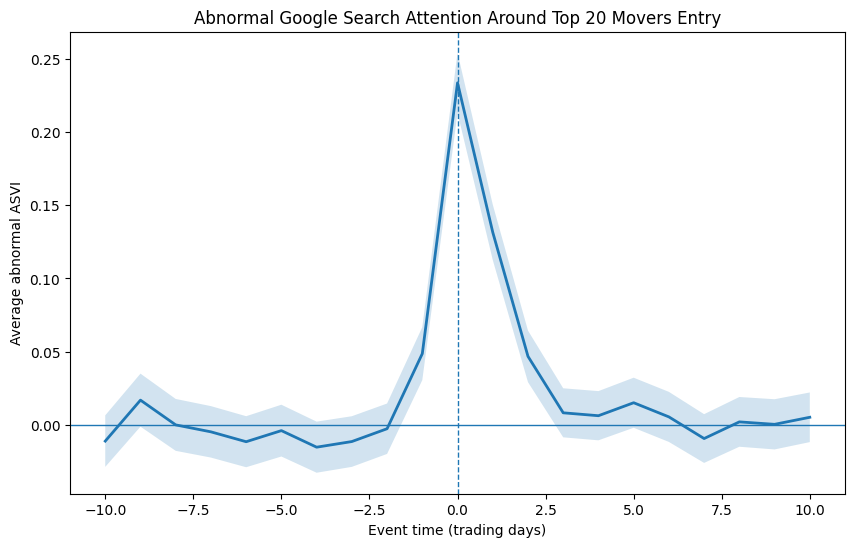

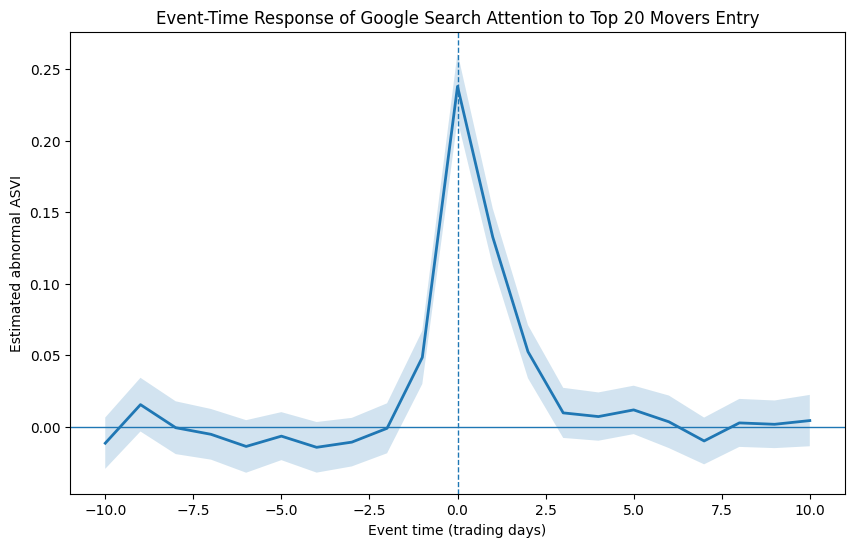

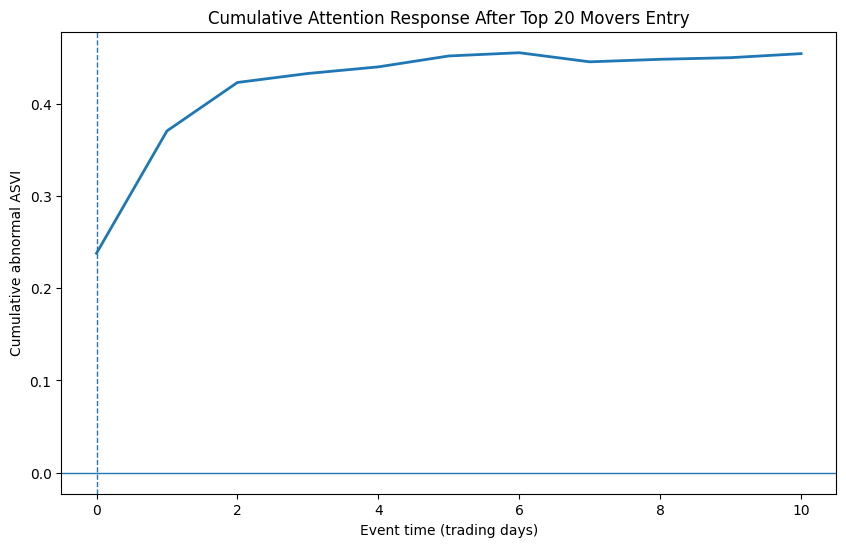

In [14]:
# ============================================================
# 1. PREPARE PANEL
# ============================================================
def make_ab_svi(s):
    mu = s.shift(1).rolling(window=20, min_periods=20).mean()
    ratio = s / mu
    ratio[(mu <= 0) | (~np.isfinite(ratio))] = np.nan
    return np.log1p(ratio)

df1['asvi_t'] = df1.groupby('ticker')['svi'].transform(make_ab_svi)

# keep only required columns
df1 = df1.dropna(subset=['ticker', 'date', 'top_20_mover', 'asvi_t']).copy()

# optional: keep stocks with enough observations
stock_counts = df1.groupby('ticker')['date'].transform('count')
df1 = df1[stock_counts >= 60].copy()

# trading-day index within stock
df1 = df1.sort_values(['ticker', 'date']).reset_index(drop=True)
df1['td_index'] = df1.groupby('ticker').cumcount()

# ============================================================
# 2. DEFINE EVENT: ENTRY INTO TOP_20_MOVER
# ============================================================

# event occurs when stock enters top_20_mover after not being in it yesterday
df1['top_20_mover'] = df1['top_20_mover'].astype(int)

df1['event_onset'] = (
    (df1['top_20_mover'] == 1) &
    (df1.groupby('ticker')['top_20_mover'].shift(1).fillna(0) == 0)
).astype(int)

# ============================================================
# 3. ENFORCE NON-OVERLAP
# ============================================================

event_window = 10
min_gap = 2 * event_window + 1   # 21 trading days

def keep_non_overlapping_events(g, min_gap):
    g = g.sort_values('td_index').copy()
    event_positions = g.loc[g['event_onset'] == 1, 'td_index'].tolist()

    keep = []
    last_kept = -np.inf
    for pos in event_positions:
        if pos - last_kept >= min_gap:
            keep.append(pos)
            last_kept = pos

    g['event_keep'] = g['td_index'].isin(keep).astype(int)
    return g

df1 = df1.groupby('ticker', group_keys=False).apply(
    keep_non_overlapping_events,
    min_gap=min_gap
)

# ============================================================
# 4. RESIDUALIZE ASVI_T WITH STOCK AND DATE FIXED EFFECTS
# ============================================================

df_fe = df1.set_index(['ticker', 'date']).sort_index()

y = df_fe['asvi_t']
X = pd.DataFrame({'const': 1.0}, index=df_fe.index)

fe_model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

fe_res = fe_model.fit()

# abnormal attention = FE residual
df_fe['asvi_abn'] = fe_res.resids
df1 = df_fe.reset_index()

# ============================================================
# 5. BUILD EVENT-TIME PANEL
# ============================================================

window_list = []

for ticker, g in df1.groupby('ticker'):
    g = g.sort_values('td_index').reset_index(drop=True)
    event_rows = g.index[g['event_keep'] == 1].tolist()

    for row_idx in event_rows:
        event_td = g.loc[row_idx, 'td_index']
        event_date = g.loc[row_idx, 'date']

        lower_td = event_td - event_window
        upper_td = event_td + event_window

        win = g[(g['td_index'] >= lower_td) & (g['td_index'] <= upper_td)].copy()
        win['event_time'] = win['td_index'] - event_td
        win['event_id'] = f"{ticker}_{event_date.strftime('%Y%m%d')}"
        win['event_ticker'] = ticker
        win['event_date'] = event_date

        window_list.append(
            win[['event_id', 'event_ticker', 'event_date', 'date',
                 'event_time', 'top_20_mover', 'asvi_t', 'asvi_abn']]
        )

event_panel = pd.concat(window_list, ignore_index=True)

# keep only complete windows
complete_counts = event_panel.groupby('event_id')['event_time'].nunique()
complete_ids = complete_counts[complete_counts == (2 * event_window + 1)].index
event_panel_bal = event_panel[event_panel['event_id'].isin(complete_ids)].copy()

# ============================================================
# 6. DESCRIPTIVE EVENT-TIME AVERAGES
# ============================================================

avg_path = (
    event_panel_bal
    .groupby('event_time')
    .agg(
        avg_asvi=('asvi_t', 'mean'),
        avg_asvi_abn=('asvi_abn', 'mean'),
        sd_asvi_abn=('asvi_abn', 'std'),
        n_events=('event_id', 'nunique')
    )
    .reset_index()
    .sort_values('event_time')
)

avg_path['se_asvi_abn'] = avg_path['sd_asvi_abn'] / np.sqrt(avg_path['n_events'])
avg_path['ci_low'] = avg_path['avg_asvi_abn'] - 1.96 * avg_path['se_asvi_abn']
avg_path['ci_high'] = avg_path['avg_asvi_abn'] + 1.96 * avg_path['se_asvi_abn']

avg_path['cum_avg_asvi_abn'] = np.nan
mask = avg_path['event_time'] >= 0
avg_path.loc[mask, 'cum_avg_asvi_abn'] = avg_path.loc[mask, 'avg_asvi_abn'].cumsum()

print(avg_path)

# ============================================================
# 7. LOCAL-PROJECTION EVENT-STUDY ESTIMATES
# ============================================================

lp_df = df1.copy()
lp_df['event_keep'] = lp_df['event_keep'].astype(int)

lp_df['ticker_clust'] = lp_df['ticker'].astype('category').cat.codes
lp_df['date_clust'] = lp_df['date'].astype('category').cat.codes

horizons = list(range(-event_window, event_window + 1))
lp_results = []

for h in horizons:
    temp = lp_df[['ticker', 'date', 'asvi_abn', 'event_keep',
                  'ticker_clust', 'date_clust']].copy()

    # outcome at t+h, aligned to row t
    temp['y_h'] = temp.groupby('ticker')['asvi_abn'].shift(-h)
    temp = temp.dropna(subset=['y_h', 'event_keep']).copy()

    X = sm.add_constant(temp[['event_keep']])
    y = temp['y_h']

    res = sm.OLS(y, X).fit(
        cov_type='cluster',
        cov_kwds={'groups': temp[['ticker_clust', 'date_clust']]}
    )

    beta = res.params['event_keep']
    se = res.bse['event_keep']

    lp_results.append({
        'event_time': h,
        'beta': beta,
        'se': se,
        'ci_low': beta - 1.96 * se,
        'ci_high': beta + 1.96 * se,
        'n_obs': len(temp)
    })

lp_results = pd.DataFrame(lp_results).sort_values('event_time').copy()
lp_results['cum_beta'] = np.nan
mask = lp_results['event_time'] >= 0
lp_results.loc[mask, 'cum_beta'] = lp_results.loc[mask, 'beta'].cumsum()

print(lp_results)

# ============================================================
# 8. PLOTS
# ============================================================

# Average abnormal ASVI around Top 20 entry
plt.figure(figsize=(10, 6))
plt.plot(avg_path['event_time'], avg_path['avg_asvi_abn'], linewidth=2)
plt.fill_between(
    avg_path['event_time'],
    avg_path['ci_low'],
    avg_path['ci_high'],
    alpha=0.2
)
plt.axvline(0, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.xlabel('Event time (trading days)')
plt.ylabel('Average abnormal ASVI')
plt.title('Abnormal Google Search Attention Around Top 20 Movers Entry')
plt.show()

# Local-projection estimates
plt.figure(figsize=(10, 6))
plt.plot(lp_results['event_time'], lp_results['beta'], linewidth=2)
plt.fill_between(
    lp_results['event_time'],
    lp_results['ci_low'],
    lp_results['ci_high'],
    alpha=0.2
)
plt.axvline(0, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.xlabel('Event time (trading days)')
plt.ylabel('Estimated abnormal ASVI')
plt.title('Event-Time Response of Google Search Attention to Top 20 Movers Entry')
plt.show()

# Cumulative abnormal attention
plt.figure(figsize=(10, 6))
cum_df = lp_results[lp_results['event_time'] >= 0].copy()
plt.plot(cum_df['event_time'], cum_df['cum_beta'], linewidth=2)
plt.axvline(0, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.xlabel('Event time (trading days)')
plt.ylabel('Cumulative abnormal ASVI')
plt.title('Cumulative Attention Response After Top 20 Movers Entry')
plt.show()

These figures show, reliably, that entry into the `top_20_mover` set is associated with a sharp contemporaneous increase in abnormal Google-search attention, followed by rapid attenuation over the next one to two trading days. The spike is concentrated at event time 0, there is little evidence of a strong pre-trend, and the effect is largely gone after a few days. That is exactly the kind of short-lived salience effect one would expect from a prominently displayed list on the Robinhood app. Barber et al. argue that the app’s Top Movers display affects investor behavior, and they proxy likely inclusion using the top 20 absolute return movers among stocks above the $300 million threshold, which is the same underlying logic as my `top_20_mover` indicator.

The strongest feature of the first two plots is the timing. Abnormal `asvi_t` is close to zero before the event, jumps sharply on the event day, and decays quickly afterward. That pattern matters because it suggests that Top Movers entry is associated with an immediate attention response rather than a slow buildup. Put differently, the figure does not look like "stocks that were already becoming increasingly salient just happened to enter the list". It looks more like "entry into the salient list coincides with an attention shock". As descriptive evidence, that is strong.

The cumulative plot adds the second important point. The cumulative abnormal attention response remains positive after day 0 and rises a bit further over the next few days, but almost all of the action comes from the initial jump and the immediate day or two after it. So the economically relevant response is front-loaded. This is a burst in attention, not a prolonged regime shift in search intensity.

That said, there are two limits on what we can claim so far.

First, this is still not causal evidence. Our event is defined using a proxy for Top Movers inclusion based on extreme same-day returns among eligible stocks. The same return shock that gets a stock into the Top Movers set may itself induce Google searching. Barber et al. face a related limitation because they do not observe the actual list and use return ranks as a proxy for likely appearance.  So the correct interpretation is association in timing, not a clean treatment effect of list inclusion alone.

Second, because `top_20_mover` is built from return-based sorting, the event bundles together two things: platform salience and an underlying large price movement. Our figure therefore establishes that Top Movers episodes are attention episodes. It does not yet separate whether the attention comes from the app interface itself or from the underlying return shock.

## 3. Causal Inference

I start building my sample.

In [22]:
df2 = main.copy()
df2['date'] = pd.to_datetime(df2['date'])
df2 = df2.sort_values(['ticker', 'date']).reset_index(drop=True)
df2['size'] *= 1000 # convert size to millions

# asvi_t
df2['asvi_t'] = df2.groupby('ticker')['svi'].transform(make_ab_svi)

# previous close by stock
df2['prc_lag1'] = df2.groupby('ticker')['close_price'].shift(1)

# overnight return: from close t-1 to open t
df2['overnight_ret'] = (df2['open_price'] - df2['prc_lag1']) / df2['prc_lag1']
df2['abs_overnight_ret'] = df2['overnight_ret'].abs()

# running variable
df2['running'] = df2['size'] - 300.0   # size already in $ millions
df2['above_300'] = (df2['running'] >= 0).astype(int)

Second, I need a day-level pool of stocks plausibly eligible for the Top Movers list. I would start with one of these two definitions.

Definition A, broader and safer for RD:
I keep the top 100 stocks by absolute overnight return each day.

Definition B, tighter:
I keep the top 50.

In [23]:
# rank absolute overnight returns within each date
df2['overnight_rank'] = df2.groupby('date')['abs_overnight_ret'].rank(
    method='first', ascending=False
)

# candidate sample: top 100 overnight movers each day
df2['candidate_100'] = (df2['overnight_rank'] <= 100).astype(int)

# tighter robustness
df2['candidate_50'] = (df2['overnight_rank'] <= 50).astype(int)

For descriptive work, I keep `top_20_mover`.

In [24]:
rank_eligible = (
    df2[df2['above_300'] == 1]
    .groupby('date')['abs_overnight_ret']
    .rank(method='dense', ascending=False) # in case of ties, assign the same rank to all tied values and skip subsequent ranks
)

df2['top_20_mover'] = 0
df2.loc[rank_eligible.index, 'top_20_mover'] = (rank_eligible <= 20).astype(int)

I now prepare the regression discontinuity (RD) sample.

> Regression discontinuity designs (RDD) are a quasi-experimental pretest–posttest design that attempts to determine the causal effects of interventions by assigning a cutoff or threshold above or below which an intervention is assigned. By comparing observations lying closely on either side of the threshold, it is possible to estimate the average treatment effect in environments where random assignment to conditions is unfeasible. True causal inference using RDDs is still impossible, because the RDD cannot account for the potentially confounding effects of other variables without randomization. [Wikipedia](https://en.wikipedia.org/wiki/Regression_discontinuity_design).

I start with observations in the candidate set and within a symmetric bandwidth around the cutoff, for example $250m$ to $350m$, as in Barber et al. (2022).

In [25]:
# choose candidate definition
rd = df2[df2['candidate_100'] == 1].copy()

# drop missing core variables
rd = rd.dropna(subset=['running', 'above_300', 'asvi_t', 'userchg', 'net_buys', 'abs_overnight_ret']).copy()

# local window around cutoff
bw = 50   # $50 million on each side
rd_bw = rd[rd['running'].between(-bw, bw)].copy()

I now proceed with a visual inspection.

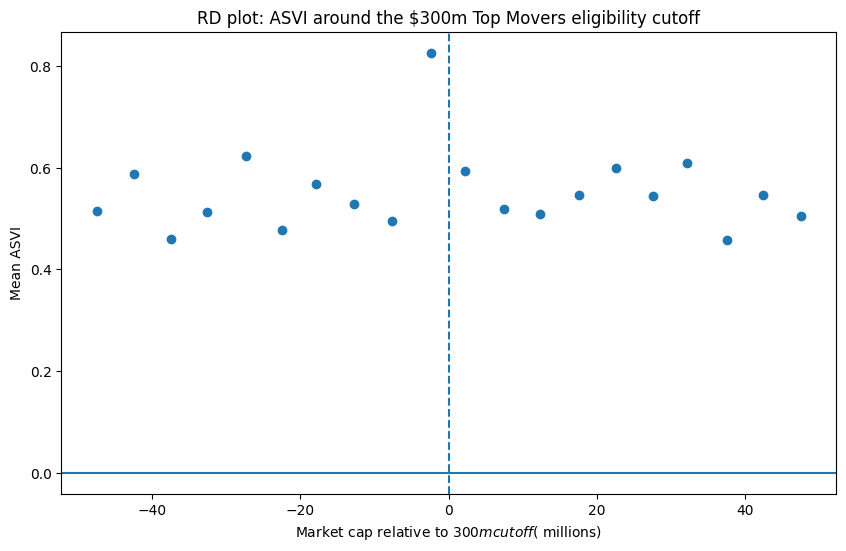

In [26]:
# simple bins
rd_bw['bin'] = pd.cut(rd_bw['running'], bins=np.arange(-bw, bw + 5, 5))
plot_df = (
    rd_bw.groupby('bin', observed=True)
    .agg(
        running_mean=('running', 'mean'),
        asvi_mean=('asvi_t', 'mean'),
        n=('asvi_t', 'size')
    )
    .dropna()
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))
plt.scatter(plot_df['running_mean'], plot_df['asvi_mean'])
plt.axvline(0, linestyle='--')
plt.axhline(0, linestyle='-')
plt.xlabel('Market cap relative to $300m cutoff ($ millions)')
plt.ylabel('Mean ASVI')
plt.title('RD plot: ASVI around the $300m Top Movers eligibility cutoff')
plt.show()

In [27]:
def local_linear_rd(data, yvar):
    temp = data[[yvar, 'running', 'above_300', 'ticker', 'date']].dropna().copy()
    temp['interaction'] = temp['running'] * temp['above_300']

    X = sm.add_constant(temp[['above_300', 'running', 'interaction']])
    y = temp[yvar]

    # cluster by date as baseline; later also try two-way if desired
    res = sm.OLS(y, X).fit(
        cov_type='cluster',
        cov_kwds={'groups': temp['date']}
    )
    return res

res_asvi = local_linear_rd(rd_bw, 'asvi_t')
print(res_asvi.summary())

res_userchg = local_linear_rd(rd_bw, 'userchg')
print(res_userchg.summary())

res_netbuys = local_linear_rd(rd_bw, 'net_buys')
print(res_netbuys.summary())

                            OLS Regression Results                            
Dep. Variable:                 asvi_t   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.230
Date:                Wed, 25 Mar 2026   Prob (F-statistic):              0.298
Time:                        23:00:01   Log-Likelihood:                -2259.9
No. Observations:                2029   AIC:                             4528.
Df Residuals:                    2025   BIC:                             4550.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.6364      0.050     12.719      

#### Robustness Checks

**#1 bandwidth sensitivity**

In [28]:
bandwidths = [25, 40, 50, 75, 100]
results = []

for bw in bandwidths:
    temp = rd[rd['running'].between(-bw, bw)].copy()
    res = local_linear_rd(temp, 'asvi_t')
    results.append({
        'bandwidth': bw,
        'tau': res.params['above_300'],
        'se': res.bse['above_300'],
        'pval': res.pvalues['above_300'],
        'n': int(res.nobs)
    })

bw_table = pd.DataFrame(results)
print(bw_table)

   bandwidth       tau        se      pval     n
0         25 -0.225868  0.098692  0.022102  1004
1         40 -0.127455  0.073242  0.081826  1616
2         50 -0.080760  0.067276  0.229975  2029
3         75 -0.062258  0.055439  0.261436  3103
4        100 -0.038144  0.048025  0.427045  4279


**#2 Placebo Outcomes**

In [29]:
# create lags
for var in ['asvi_t', 'userchg', 'daily_buys', 'num_news']:
    if var in rd.columns:
        rd[f'{var}_lag1'] = rd.groupby('ticker')[var].shift(1)

placebos = [c for c in ['asvi_t_lag1', 'userchg_lag1', 'daily_buys_lag1', 'num_news_lag1'] if c in rd.columns]

for var in placebos:
    temp = rd[rd['running'].between(-50, 50)].copy()
    res = local_linear_rd(temp, var)
    print(f'\nPlacebo outcome: {var}')
    print(res.summary().tables[1])


Placebo outcome: asvi_t_lag1
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.5363      0.051     10.573      0.000       0.437       0.636
above_300      -0.0111      0.068     -0.164      0.870      -0.144       0.122
running        -0.0007      0.002     -0.441      0.659      -0.004       0.003
interaction     0.0017      0.002      0.738      0.460      -0.003       0.006

Placebo outcome: userchg_lag1
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          90.3713     70.086      1.289      0.197     -46.994     227.737
above_300      44.8206     79.718      0.562      0.574    -111.423     201.065
running         0.1057      1.730      0.061      0.951      -3.285       3.496
interaction    -0.8010      1.854     -0.432      0.666    

**#3 density and balance around the cutoff**

In [30]:
density_check = (
    rd.assign(bin=pd.cut(rd['running'], bins=np.arange(-100, 101, 10)))
      .groupby('bin', observed=True)
      .size()
      .reset_index(name='count')
)
print(density_check)

            bin  count
0   (-100, -90]    310
1    (-90, -80]    286
2    (-80, -70]    225
3    (-70, -60]    271
4    (-60, -50]    236
5    (-50, -40]    232
6    (-40, -30]    226
7    (-30, -20]    203
8    (-20, -10]    200
9      (-10, 0]    175
10      (0, 10]    211
11     (10, 20]    194
12     (20, 30]    213
13     (30, 40]    194
14     (40, 50]    181
15     (50, 60]    173
16     (60, 70]    202
17     (70, 80]    203
18     (80, 90]    177
19    (90, 100]    167


**#4 matched-sample robustness on overnight returns**

The fourth is matched-sample robustness on overnight returns. Since large overnight moves drive Top Movers competition, I compare stocks just above and just below the cutoff with similar `abs_overnight_ret`. A simple first pass is to residualize the outcome on flexible controls for `abs_overnight_ret`, or include it directly.

In [31]:
def local_linear_rd_with_return_control(data, yvar):
    temp = data[[yvar, 'running', 'above_300', 'abs_overnight_ret', 'date']].dropna().copy()
    temp['interaction'] = temp['running'] * temp['above_300']

    X = sm.add_constant(temp[['above_300', 'running', 'interaction', 'abs_overnight_ret']])
    y = temp[yvar]

    res = sm.OLS(y, X).fit(
        cov_type='cluster',
        cov_kwds={'groups': temp['date']}
    )
    return res

res_asvi_ctrl = local_linear_rd_with_return_control(
    rd[rd['running'].between(-50, 50)].copy(),
    'asvi_t'
)
print(res_asvi_ctrl.summary())

                            OLS Regression Results                            
Dep. Variable:                 asvi_t   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     11.93
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           3.01e-09
Time:                        23:12:37   Log-Likelihood:                -2232.0
No. Observations:                2029   AIC:                             4474.
Df Residuals:                    2024   BIC:                             4502.
Df Model:                           4                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.5140      0.05

In my sample, I do not detect a robust discontinuity in Google-search attention at the Top Movers eligibility cutoff, even though the platform may still affect Robinhood trading directly. A plausible explanation is that the app’s salience effect operates primarily within the brokerage interface and is too narrow or noisy to generate a detectable shift in aggregate Google search activity.